# Математическая статистика для анализа больших данных
## Задание 3. Семинар
### Оценка максимального правдоподобия. Метод Ньютона

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

In [ ]:
# Bot check

# HW_ID: sbd_sem3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Метод Ньютона. Пример

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

import itertools

import warnings
warnings.simplefilter("ignore")

%matplotlib inline

На сегодняшний день возобновляемые источники энергии становятся все более востребованными. К таким источникам относятся, например, ветрогенераторы. Однако их мощность очень трудно прогнозировать. В частности, выработка энергии при помощи ветрогенератора сильно зависит от скорости ветра. Поэтому предсказание скорости ветра является очень важной задачей. Скорость ветра часто моделируют с помощью распределения Вейбулла, которое имеет плотность:
$$p_\theta(x) = \frac{kx^{k-1}}{\lambda^k} e^{-(x/\lambda)^k} I \{x \geq 0\},$$
где $\theta = (k, \lambda)$ &mdash; двумерный параметр. К сожалению, найти точную оценку максимального правдоподобия на $\theta$ не получится. Поэтому сравним поиск оценки максимального правдоподобия приближенно с помощью поиска по сетке и с помощью метода Ньютона.

За распределение Вейбулла отвечает класс `weibull_min` из модуля `scipy.stats`, которое задается так: `weibull_min(c=`$k$ `, scale=`$\lambda$ `)`.

Для начала загрузим выборку (данные по средней скорости ветра в Вологде с 2000 по 2003 год):

In [ ]:
sample = pd.read_csv('data/11.csv')
sample = sample[(2000 <= sample['Year']) & (sample['Year'] <= 2003)]
sample = sample['Mean'].values
sample = sample[~np.isnan(sample)]

FileNotFoundError: [Errno 2] No such file or directory: 'data/11.csv'

### Поиск по сетке

Найдём оценку максимального правдоподобия параметра $\theta = (k, \lambda)$ с точностью $10^{-5}$ при помощи поиска по двумерной сетке.

Двумерную сетку создадим с помощью функции `numpy.mgrid[from:to:step, from:to:step]`. Если попробовать сразу создать сетку с шагом $10^{-5},$ то может не хватить памяти. Поэтому найдём сначала максимум по сетке с большим шагом, затем сделаем сетку с маленьким шагом в окрестности найденной точки.

Функция `numpy.argmax` выдает не очень информативный индекс, поэтому будем использовать следующую функцию.

In [ ]:
def cool_argmax(array):
    return np.unravel_index(np.argmax(array), array.shape)

Подсчетаем ОМП по сетке:

In [ ]:
wind = sample[:, np.newaxis, np.newaxis]
# текущее k и границы параметров для перебора
result_k, from_k, to_k = 0, 0.1, 10
# текущее лямбда и границы
result_lambda, from_lambda, to_lambda = 0, 0.1, 10
step = 0.1  # шаг сетки

# Несколько итераций поиска по локальной сетке с уменьшающимся шагом
for i in range(6):
    # cоздаем сетку
    grid = np.mgrid[from_k:to_k:step, from_lambda:to_lambda:step]
    ## подсчет правдоподобия в точках сетки
    likelihood = sps.weibull_min(
        c=grid[0], scale=grid[1]).logpdf(wind).sum(axis=0)
    max_index = cool_argmax(likelihood)  # поиск максимума

    # обновление текущих параметров
    result_k = grid[0, max_index[0], max_index[1]]
    result_lambda = grid[1, max_index[0], max_index[1]]
    # новые границы для поиска по сетке
    from_k, to_k = result_k - step, result_k + step
    from_lambda, to_lambda = result_lambda - step, result_lambda + step
    # уменьшаем шаг сетки
    step *= 0.1

print("k = {:.5f}, lambda = {:.5f}".format(result_k, result_lambda))

Посмотрим график плотности и сравним с гистограммой:

In [ ]:
grid = np.linspace(0, 23, 200)
plt.figure(figsize=(12, 6))

plt.hist(sample, bins=30, density=True, label='hist')
plt.plot(grid, sps.weibull_min.pdf(grid, c=result_k, scale=result_lambda),
         color='green', alpha=0.3, lw=2,
         label="weibull pdf; $k = {:.5f}, \\lambda = {:.5f}$".format(
             result_k, result_lambda))

plt.legend()
plt.title("Оценка распределения среднесуточной скорости ветра")
plt.xlabel("Среднесуточная скорость ветра")
plt.xticks()
plt.yticks()
plt.show()

### Метод Ньтона

Обозначим $\widehat{\theta} = \left(\widehat{\lambda}, \widehat{k}\right)$ &mdash; ОМП. Запишем уравнение правдоподобия, приравняв все частные производные в точке экстремума логарифмической функции правдоподобия к $0$. Используя одно из равенств, можно выразить $\widehat{\lambda}$ через значения $X_1, \dots, X_n, \widehat{k}$; подставив это выражение в другое равенство, получить уравнение на $\widehat{k}$. Решив это уравнение приближенно с помощью метода Ньютона, получим $\widehat{k}$, а значит, и $\widehat{\lambda}$.

**Решение:**

$\newcommand\diff[2]{\frac{\partial{#1}}{\partial{#2}}}$

Логарифмическая функция правдоподобия:
$$\ell_X(\theta) = n \ln k - n k \ln \lambda + (k - 1) \sum_{i=1}^n \ln X_i - \frac{1}{\lambda^k} \sum_{i=1}^n {X_i}^k$$

Выписав условие на производную (уровнение правдоподобия), получаем выражение $\lambda$ через $k$:
$$
\widehat{\lambda} = \sqrt[k]{ \Big(\overline{X^{\widehat{k}}}\Big) }
$$

Теперь решим уровнение на $k$ с помощью метода Ньютона

Уравнение, которому должно удовлетворять $\widehat{k}$:
$$f(\widehat{k}) := \frac{1}{n} \diff{\ell_X(\theta)}{k} \Bigg|_{\lambda=\widehat{\lambda}} = \frac{1}{\widehat{k}} + \frac{1}{n} \sum_{i=1}^n \ln X_i - \frac{\sum_{i=1}^n X_i^{\widehat{k}} \ln X_i}{\sum_{i=1}^n X_i^{\widehat{k}}} = 0.$$

Производная $f$:
$$f'(k) = -\frac{1}{{k}^2} - \frac{(\sum_{i=1}^n X_i^{k} \ln^2 X_i)(\sum_{i=1}^n X_i^{k}) - ({\sum_{i=1}^n X_i^{k} \ln X_i})^2}{(\sum_{i=1}^n X_i^{k})^2}$$

Шаг метода Ньютона:
$$\widehat{k}_{n+1} = \widehat{k}_{n} - \frac{f(\widehat{k}_{n})}{f'(\widehat{k}_{n})}.$$

Функции, вычисляющие $f$ и $f'$ для $X_1, \dots, X_n$ в точке $k$:

In [ ]:
def weibull_apprx(sample, k):
    return 1 / k + np.log(sample).sum() / sample.size - \
        np.sum(sample ** k * np.log(sample)) / np.sum(sample ** k)

def weibull_apprx_dv(sample, c, k):
    return - 1 / k ** 2 - (np.sum(sample ** k * np.log(sample) ** 2) * \
                           np.sum(sample ** k) - \
                           np.sum(sample ** k * np.log(sample)) ** 2) / \
                           np.sum(sample ** k) ** 2

In [ ]:
k_new = 1
f = weibull_apprx(sample, k_new)

while True:
    # Шаг итерации метода Ньютона
    k_old = k_new
    k_new = k_old - weibull_apprx(sample, k_old) / \
                    weibull_apprx_dv(sample, k_old, k_old)
    # Провеярем условие сходимости
    if abs(k_new - k_old) < 1e-10:
        break
# Выразим лямбда
lambd = np.mean(sample ** k_new) ** (1 / k_new)

print("k = {:.5f}, lambda = {:.5f}".format(k_new, lambd))

**Вывод:** Оценка максимального правдоподобия параметров распределения по выборке среднесуточной скорости ветра  &mdash; $k = 2.62502, \lambda = 6.89860$, причем результаты, полученные разными методами вычисления, совпадают.

##  Задача 1 (самостоятельное решение)

Дана параметрическая модель и 3 выборки, состоящие из 2-3 наблюдений. Для удобства, выборки представлены в виде python-кода — каждая выборка записана как список ее элементов; множество выборок представлено как список списков, соответствующих выборкам из множества. Нужно для каждой выборки построить график функции правдоподобия.

*a).* Параметрическая модель $\mathcal{N}(\theta, 1)$, выборки: `[[-1, 1], [-5, 5], [-1, 5]]`

*b).* Параметрическая модель $Exp(\theta)$, выборки: `[[1, 2], [0.1, 1], [1, 10]]`

*c).* Параметрическая модель $U[0, \theta]$, выборки: `[[0.2, 0.8], [0.5, 1], [0.5, 1.3]]`

*d).* Параметрическая модель $Bin(5, \theta)$, выборки: `[[0, 1], [5, 5], [0, 5]]`

*e).* Параметрическая модель $Pois(\theta)$, выборки: `[[0, 1], [0, 10], [5, 10]]`

*f).* Параметрическая модель $Сauchy(\theta)$, где $\theta$ — параметр сдвига, выборки: `[[-0.5, 0.5], [-2, 2], [-4, 0, 4]]`

Выполнить задание, не создавая много кода, поможет следующая функция.

In [ ]:
def draw_likelihood(density_function, grid, samples, label):
    '''
    Изображает график функции правдоподобия для каждой из 3 выборок.

    Аргументы:
        density_function --- функция, считающая плотность
            (обычную или дискретную). На вход данная функция
            должна принимать массив размера (1, len_sample)
            и возвращать массив размера (len_grid, len_sample).
        grid --- массив размера (len_grid, 1), являющийся
                 сеткой для построения графика;
        samples --- три выборки;
        label --- latex-код параметрической модели.
    '''

    assert len(samples) == 3, "Число выборок не равно 3."

    plt.figure(figsize=(18, 5))
    for i, sample in enumerate(samples):
        sample = np.array(sample)[np.newaxis, :]
        likelihood = np.prod(density_function(sample), axis=1)

        plt.subplot(1, 3, i+1)
        plt.plot(grid, likelihood)
        plt.xlabel('$\\theta$', fontsize=16)
        plt.grid(ls=':')
        plt.title(label + ', sample=' + str(sample.flatten()), fontsize=16)
    plt.show()


Первый пункт можно выполнить с помощью следующего кода:

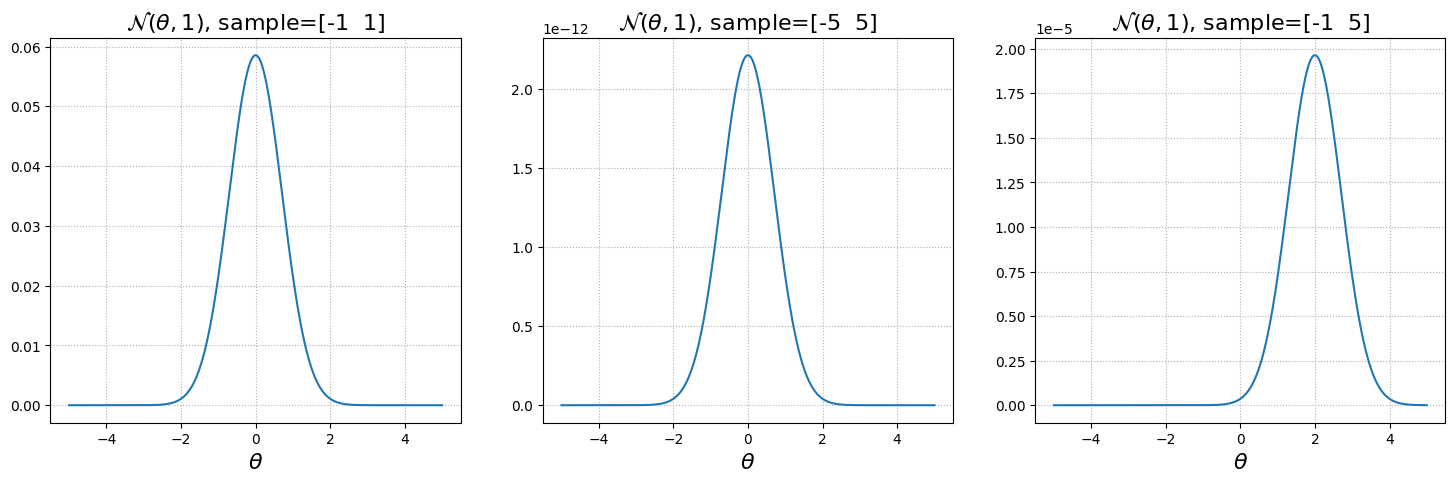

In [ ]:
grid = np.linspace(-5, 5, 1000).reshape((-1, 1))
draw_likelihood(sps.norm(loc=grid).pdf, grid,
                [[-1, 1], [-5, 5], [-1, 5]], '$\\mathcal{N}(\\theta, 1)$')

**Вывод**:

Выполните остальные:

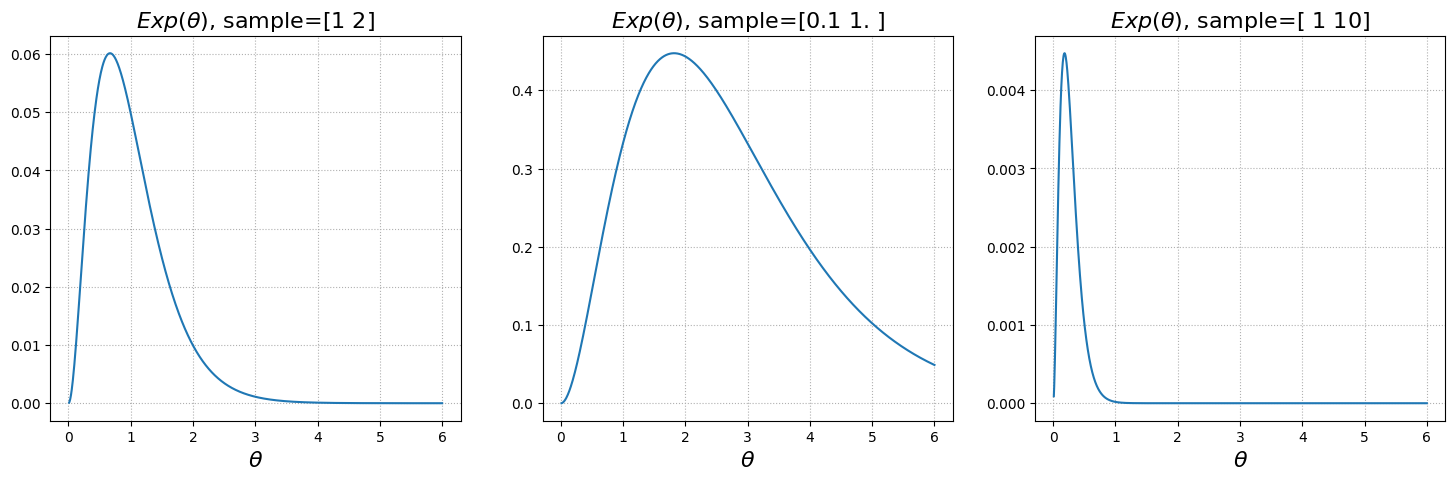

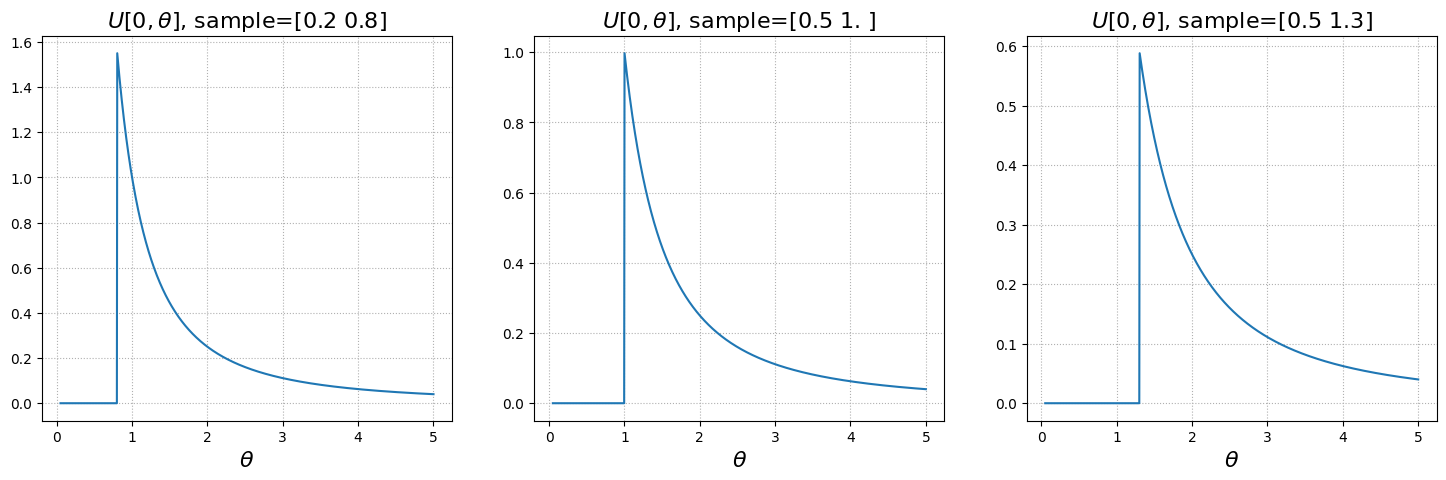

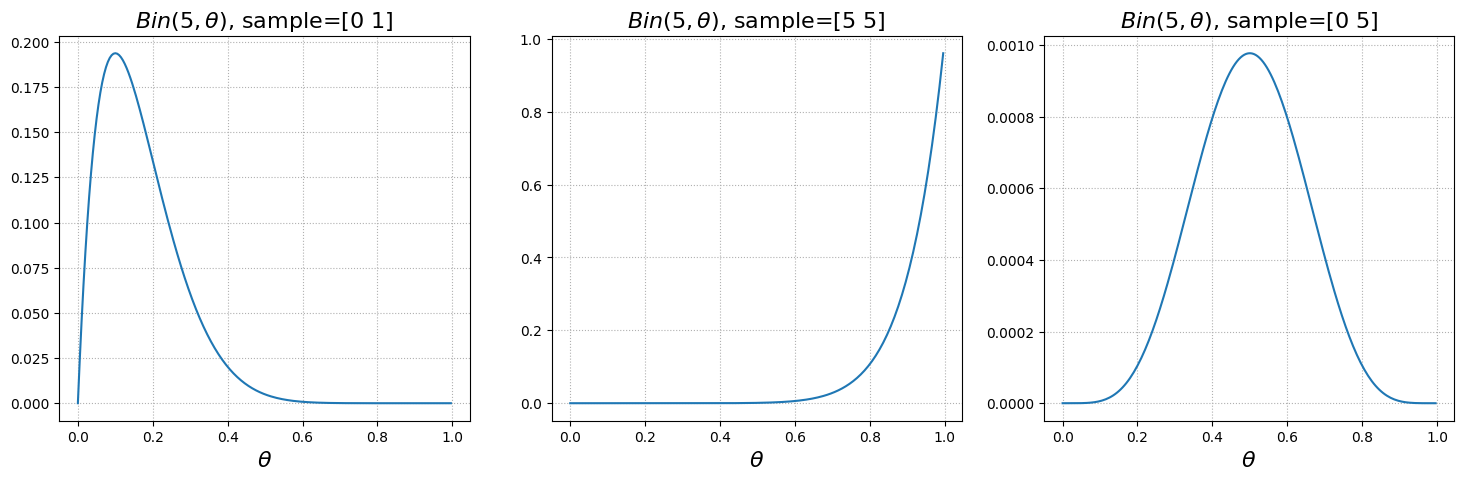

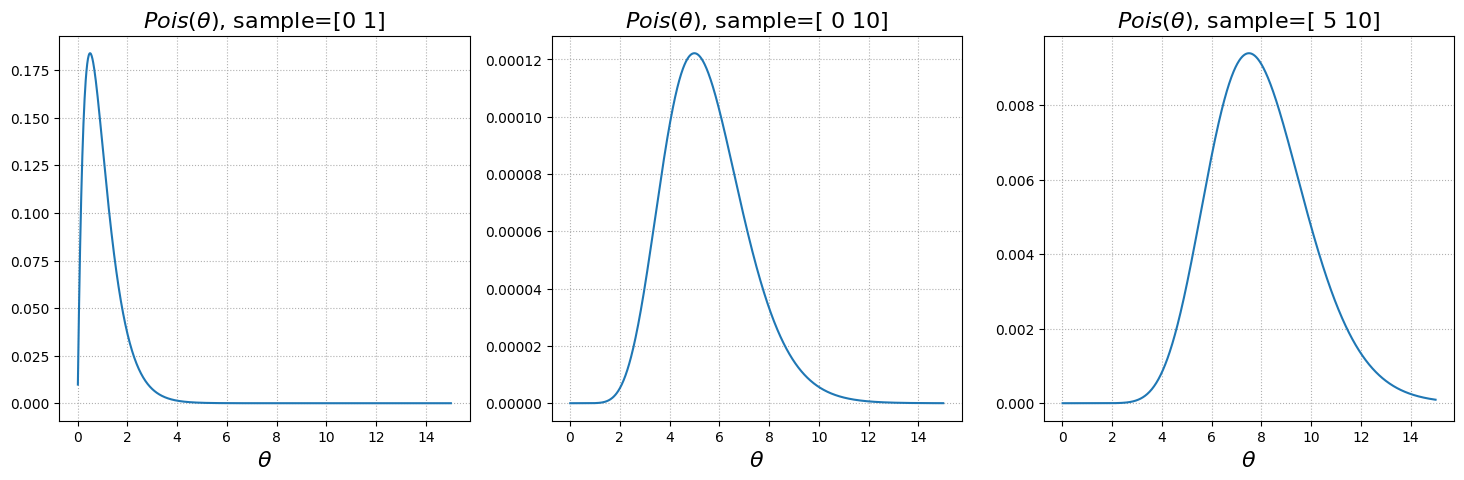

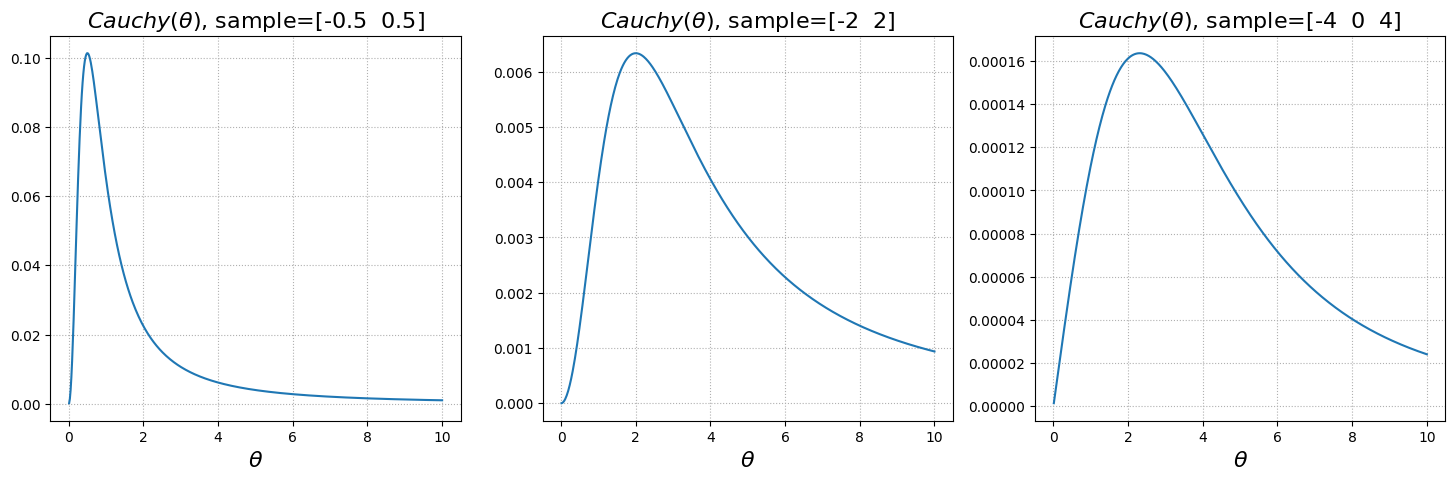

In [21]:
# b)
grid = np.linspace(0.01, 6, 1000).reshape((-1, 1))
draw_likelihood(sps.expon(scale=1/grid).pdf, grid,
                [[1, 2], [0.1, 1], [1, 10]], '$Exp(\\theta)$')

# c)
grid = np.linspace(0.05, 5, 1000).reshape((-1,1))
draw_likelihood(sps.uniform(loc=0, scale=grid).pdf, grid,
                [[0.2, 0.8], [0.5, 1], [0.5, 1.3]], '$U[0, \\theta]$')

# d)
grid = np.linspace(0, 5, 1000).reshape((-1,1))
draw_likelihood(sps.binom(n=5, p=grid).pmf, grid,
                [[0,1], [5,5], [0,5]], '$Bin(5, \\theta)$')

# e)
grid = np.linspace(0.01, 15, 1000).reshape((-1,1))
draw_likelihood(sps.poisson(mu=grid).pmf, grid,
                [[0,1], [0,10], [5,10]], '$Pois(\\theta)$')

# f)
grid = np.linspace(-10, 10, 1000).reshape((-1,1))
draw_likelihood(sps.cauchy(scale=grid).pdf, grid,
                [[-0.5, 0.5], [-2, 2], [-4, 0, 4]], '$Cauchy(\\theta)$')


Коротко прокомментируйте каждый из полученных графиков. Сделайте вывод о том, как функция правдоподобия для каждой модели зависит от выборки. Является ли функция правдоподобия плотностью?

Функция правдоподобия зависит от выборки, отражая влияние наблюдаемых данных на оценку параметра $ \theta $.

Для нормального распределения $ N(\theta, 1) $ функция правдоподобия достигает максимума в точке, симметричной относительно данных. Например, для выборки $ [-1, 1] $ максимум достигается при $ \theta = 0 $, так как данные симметричны относительно нуля. Увеличение разброса данных, как в выборке $ [-5, 5] $, снижает амплитуду правдоподобия, но его максимум остаётся на среднем значении. В случае смещения данных, как в выборке $ [-1, 5] $, максимум также смещается.

Для экспоненциального распределения $ Exp(\theta) $ функция правдоподобия отражает среднее значение выборки. Маленькие значения, как в выборке $ [0.1, 1] $, приводят к максимуму при меньших $ \theta $, тогда как выборки с большим разбросом, например, $ [1, 10] $, смещают максимум к большим $ \theta $ и делают его более пологим.

Для равномерного распределения $ U[0, \theta] $ функция правдоподобия обнуляется для $ \theta $, меньшего максимума выборки. После этого правдоподобие убывает, отражая уменьшение плотности при увеличении $ \theta $. Это видно на примере выборок $ [0.5, 1] $ и $ [0.5, 1.3] $, где правдоподобие обнуляется при $ \theta $ меньше максимального наблюдения.

В биномиальной модели $ Bin(5, \theta) $ правдоподобие отражает частоту успехов и неудач в выборке. В выборке $ [5, 5] $ максимум достигается при $ \theta = 1 $, а в случае $ [0, 1] $ — при промежуточном значении $ \theta $. При равной частоте успехов и неудач, как в $ [0, 5] $, максимум правдоподобия находится около $ \theta = 0.5 $.

Для пуассоновского распределения $ Pois(\theta) $ максимум правдоподобия соответствует среднему выборочному значению. Выборка $ [0, 1] $ даёт максимум при $ \theta \approx 0.5 $, а выборка $ [5, 10] $ — при $ \theta \approx 7.5 $, что отражает увеличение наблюдаемых значений.

В распределении Коши $ Cauchy(\theta) $ правдоподобие имеет выраженные пики около наблюдений. Выборки $ [-0.5, 0.5] $ и $ [-2, 2] $ дают максимум при $ \theta = 0 $, поскольку данные симметричны относительно нуля. В выборке $ [-4, 0, 4] $ разброс увеличивается, но максимум остаётся на $ \theta = 0 $, хотя график становится более пологим.


Таким образом, функция правдоподобия в каждой модели по-разному зависит от выборки, отражая специфические свойства соответствующего распределения и влияние наблюдаемых данных на оценку параметра $ \theta $. Важно отметить, что функция правдоподобия не является плотностью вероятности по параметру $ \theta $. Она не интегрируется до единицы по $ \theta $ и не представляет вероятность самого параметра. Функция правдоподобия служит инструментом для оценки того, насколько хорошо различные значения $ \theta $ объясняют наблюдаемые данные, и используется в методах параметрической статистики для нахождения оценок максимального правдоподобия, но не является распределением параметра $ \theta $.
